In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, roc_curve, auc
print('Успешные импорты!')

Успешные импорты!


In [2]:
df_orig = pd.read_csv('/home/kota/ml_project/projects/SVM_project/UniversalBank.csv')
df = df_orig.copy()
df.head(15)

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
5,6,37,13,29,92121,4,0.4,2,155,0,0,0,1,0
6,7,53,27,72,91711,2,1.5,2,0,0,0,0,1,0
7,8,50,24,22,93943,1,0.3,3,0,0,0,0,0,1
8,9,35,10,81,90089,3,0.6,2,104,0,0,0,1,0
9,10,34,9,180,93023,1,8.9,3,0,1,0,0,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal Loan       5000 non-null   int64  
 10  Securities Account  5000 non-null   int64  
 11  CD Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [4]:
target_name = 'Personal Loan'
X = df.drop(columns = [target_name, 'ID', 'ZIP Code', 'Mortgage', 'CCAvg', 'Online'])
y = df[target_name]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SVC(kernel = 'rbf', random_state = 42)
print('Обучение...')
model.fit(X_train_scaled, y_train)
print('Модель успешно обучена!')


Обучение...
Модель успешно обучена!


In [6]:
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f'Общая точность модели: {accuracy:.2%}')
print('Детальный отчёт:')
print(classification_report(y_test, y_pred))

Общая точность модели: 97.80%
Детальный отчёт:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       895
           1       0.98      0.81      0.89       105

    accuracy                           0.98      1000
   macro avg       0.98      0.90      0.94      1000
weighted avg       0.98      0.98      0.98      1000



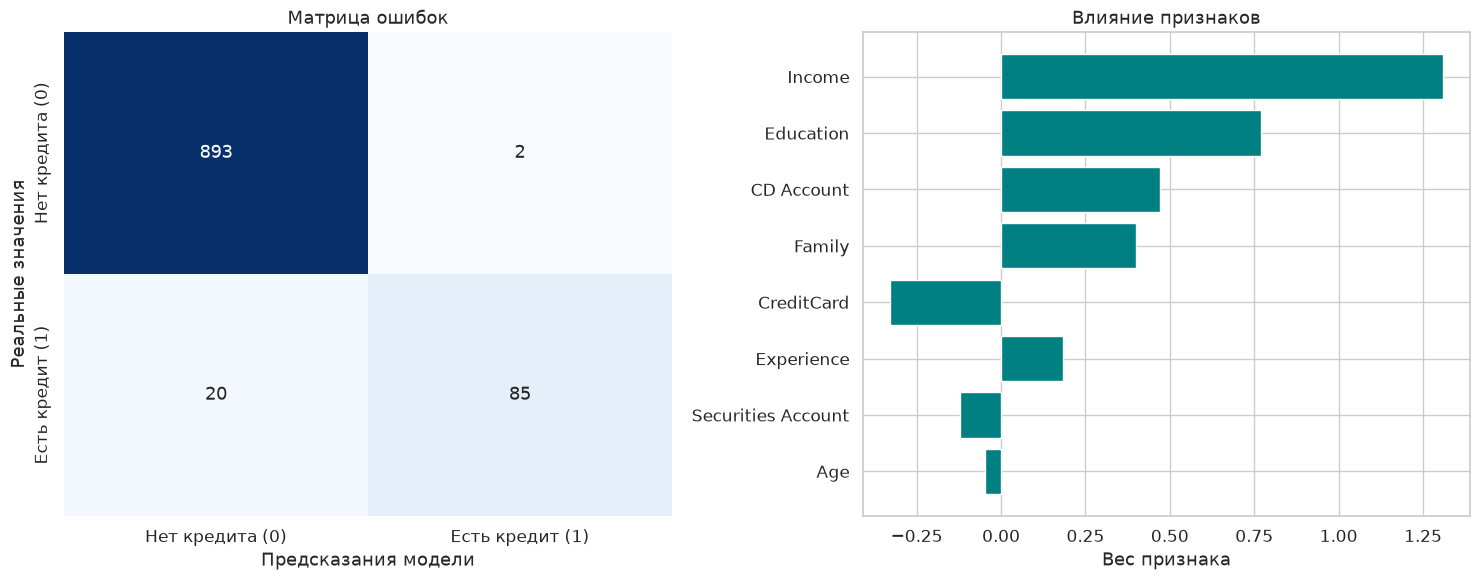

In [7]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Нет кредита (0)', 'Есть кредит (1)'],
            yticklabels=['Нет кредита (0)', 'Есть кредит (1)'])
plt.title('Матрица ошибок')
plt.ylabel('Реальные значения')
plt.xlabel('Предсказания модели')

linear_svm = SVC(kernel='linear', random_state=42)
linear_svm.fit(X_train_scaled, y_train)

importances = linear_svm.coef_[0]
features = X.columns

indices = np.argsort(abs(importances))

plt.subplot(1, 2, 2)
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title('Влияние признаков')
plt.xlabel('Вес признака')

plt.tight_layout()
plt.show()


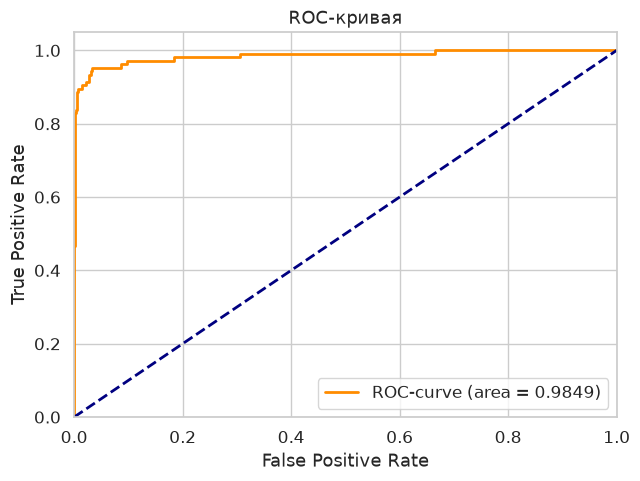

In [8]:
y_scores = model.decision_function(X_test_scaled)

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC-curve (area = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [9]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, roc_auc_score

models = {
    "Стандартная (C=1, gamma=auto)": SVC(kernel='rbf', C=1.0, random_state=42),
    "Строгая (C=100)": SVC(kernel='rbf', C=100.0, random_state=42),
    "Чувствительная (C=1, gamma=10)": SVC(kernel='rbf', C=1.0, gamma=10.0, random_state=42)
}

for name, model_instance in models.items():
    model_instance.fit(X_train_scaled, y_train)
    
    predictions = model_instance.predict(X_test_scaled)
    scores = model_instance.decision_function(X_test_scaled)
    
    auc_val = roc_auc_score(y_test, scores)
    
    print(f"========================================\nМодель: {name}")
    print(f"ROC AUC (Качество разделения): {auc_val:.4f}")
    
    report = classification_report(y_test, predictions, output_dict=True, zero_division=0)
    print(f"Точность (Precision) для кредитов: {report['1']['precision']:.2%}")
    print(f"Полнота (Recall) для кредитов: {report['1']['recall']:.2%}")


Модель: Стандартная (C=1, gamma=auto)
ROC AUC (Качество разделения): 0.9849
Точность (Precision) для кредитов: 97.70%
Полнота (Recall) для кредитов: 80.95%
Модель: Строгая (C=100)
ROC AUC (Качество разделения): 0.9790
Точность (Precision) для кредитов: 93.94%
Полнота (Recall) для кредитов: 88.57%
Модель: Чувствительная (C=1, gamma=10)
ROC AUC (Качество разделения): 0.9762
Точность (Precision) для кредитов: 88.89%
Полнота (Recall) для кредитов: 15.24%
